# Investigating the Low Pressure tracks provide by K.Hunt=>

In [1]:
import pandas as pd

# Load your file
file_path = r"D:\PHD 2025~\LOW PRESSURE TRACKS\lps_v4.1-era5-1940-2025.csv"   # <-- change this
df = pd.read_csv(file_path)

# 1. Basic info (MOST IMPORTANT)
print("\n===== DATAFRAME INFO =====")
print(df.info())

# 2. First few rows
print("\n===== HEAD =====")
print(df.head())

# 3. Column names
print("\n===== COLUMNS =====")
print(df.columns)

# 4. Shape (rows, columns)
print("\n===== SHAPE =====")
print(df.shape)

# 5. Summary statistics
print("\n===== DESCRIBE =====")
print(df.describe())

# 6. Check missing values
print("\n===== MISSING VALUES =====")
print(df.isnull().sum())


===== DATAFRAME INFO =====
<class 'pandas.DataFrame'>
RangeIndex: 2758542 entries, 0 to 2758541
Data columns (total 20 columns):
 #   Column         Dtype  
---  ------         -----  
 0   x              float64
 1   y              float64
 2   frame          int64  
 3   year           int64  
 4   month          int64  
 5   day            int64  
 6   hour           int64  
 7   max_vort       float64
 8   mean_vort_850  float64
 9   mean_vort_700  float64
 10  mean_vort_500  float64
 11  precip_1hr     float64
 12  precip_24hr    float64
 13  max_wind       float64
 14  mean_wind      float64
 15  min_mslp       float64
 16  mslp_contours  int64  
 17  over_land      int64  
 18  category       int64  
 19  track_id       int64  
dtypes: float64(11), int64(9)
memory usage: 420.9 MB
None

===== HEAD =====
       x      y  frame  year  month  day  hour   max_vort  mean_vort_850  \
0   81.5  31.25     23  1940      1    1    22  11.857572       0.798192   
1  148.5   4.25     24  19

# Data available upto August 2025!!

# Lets work with cyclone data from IMD =>

## 1.Inspecting cyclone montha=>

In [2]:
import pandas as pd

excel_path = r"D:\PHD 2025~\LOW PRESSURE TRACKS\SCS_Montha_Oct_2025.xlsx"

# 1) list sheets
xls = pd.ExcelFile(excel_path)
print("Sheets:", xls.sheet_names)

# 2) inspect each sheet
for sheet in xls.sheet_names:
    print("\n=== Sheet:", sheet, "===")
    df = pd.read_excel(excel_path)
    print(df.shape)
    print(df.columns.tolist())
    print(df.head(10))

Sheets: ['Sheet1']

=== Sheet: Sheet1 ===
(32, 15)
['Date', 'Time (UTC)', 'Lat (°N)', 'Long (°E)', 'ECP (hPa)', 'ΔP (hPa)', 'C.I. No.', 'MSW (kt)', 'Category', 'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13', 'Unnamed: 14']
         Date  Time (UTC)  Lat (°N)  Long (°E)  ECP (hPa)  ΔP (hPa) C.I. No.  \
0  25.10.2025           0      10.8       89.0       1003         3      1.5   
1  25.10.2025         300      10.8       88.8       1002         4      1.5   
2  25.10.2025         600      10.8       88.6       1002         4      1.5   
3  25.10.2025        1200      10.9       88.1       1002         4      1.5   
4  25.10.2025        1800      11.0       87.7       1004         4      1.5   
5  26.10.2025           0      11.1       87.3       1000         5        2   
6  26.10.2025         300      11.2       87.1        998         6        2   
7  26.10.2025         600      11.3       86.9        998         6        2   
8  26.10.2025        1200      

## 2. Inspecting Depression at Arabian sea=>

In [3]:
import pandas as pd

excel_path = r"D:\PHD 2025~\LOW PRESSURE TRACKS\D_Arabian_Sea_Oct_2025.xlsx"

# 1) list sheets
xls = pd.ExcelFile(excel_path)
print("Sheets:", xls.sheet_names)

# 2) inspect each sheet
for sheet in xls.sheet_names:
    print("\n=== Sheet:", sheet, "===")
    df = pd.read_excel(excel_path)
    print(df.shape)
    print(df.columns.tolist())
    print(df.head(10))

Sheets: ['Sheet1']

=== Sheet: Sheet1 ===
(50, 16)
['Date', 'Time (UTC)', 'Lat (°N)', 'Long (°E)', 'ECP (hPa)', 'ΔP (hPa)', 'C.I. No.', 'MSW (kt)', 'Category', 'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13', 'Unnamed: 14', 'Unnamed: 15']
         Date  Time (UTC)  Lat (°N)  Long (°E)  ECP (hPa)  ΔP (hPa)  C.I. No.  \
0  22.10.2025           0       8.6       67.6       1002         3       1.5   
1  22.10.2025         300       8.9       67.4       1002         3       1.5   
2  22.10.2025         600       9.0       67.0       1002         3       1.5   
3  22.10.2025        1200       9.3       67.4       1002         3       1.5   
4  22.10.2025        1800       9.5       67.6       1002         3       1.5   
5  23.10.2025           0       9.6       67.7       1001         3       1.5   
6  23.10.2025         300       9.8       67.8       1001         3       1.5   
7  23.10.2025         600      10.1       68.0       1001         3       1.5   
8  23.1

# 1. Plotting cyclone Montha

In [4]:
pip install matplotlib cartopy geopandas pandas openpyxl numpy

   ---------------------------------------- 0.0/22.9 MB ? eta -:--:--
    --------------------------------------- 0.5/22.9 MB 3.1 MB/s eta 0:00:08
   - -------------------------------------- 1.0/22.9 MB 2.6 MB/s eta 0:00:09
   -- ------------------------------------- 1.3/22.9 MB 2.2 MB/s eta 0:00:10
   -- ------------------------------------- 1.6/22.9 MB 2.0 MB/s eta 0:00:11
   --- ------------------------------------ 2.1/22.9 MB 1.9 MB/s eta 0:00:11
   ---- ----------------------------------- 2.4/22.9 MB 1.9 MB/s eta 0:00:11
   ----- ---------------------------------- 2.9/22.9 MB 1.9 MB/s eta 0:00:11
   ----- ---------------------------------- 3.1/22.9 MB 1.9 MB/s eta 0:00:11
   ------ --------------------------------- 3.7/22.9 MB 1.9 MB/s eta 0:00:11
   ------ --------------------------------- 3.7/22.9 MB 1.9 MB/s eta 0:00:11
   ------ --------------------------------- 3.9/22.9 MB 1.7 MB/s eta 0:00:11
   ------ --------------------------------- 3.9/22.9 MB 1.7 MB/s eta 0:00:11
   ---


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# Cyclone Montha with cumulative path=>

Date range : 2025-10-25 → 2025-10-30  (6 days)
Loading cyclone track data...
  → 32 points  |  2025-10-25 to 2025-10-29
Loading India shapefile...
  ⚠ Shapefile skipped: Cannot transform naive geometries.  Please set a crs on the object first.
Grid       : 2 rows × 5 cols
Figure size: 19.0 × 8.4 inches

✅ Saved → cyclone_montha_october2025.png


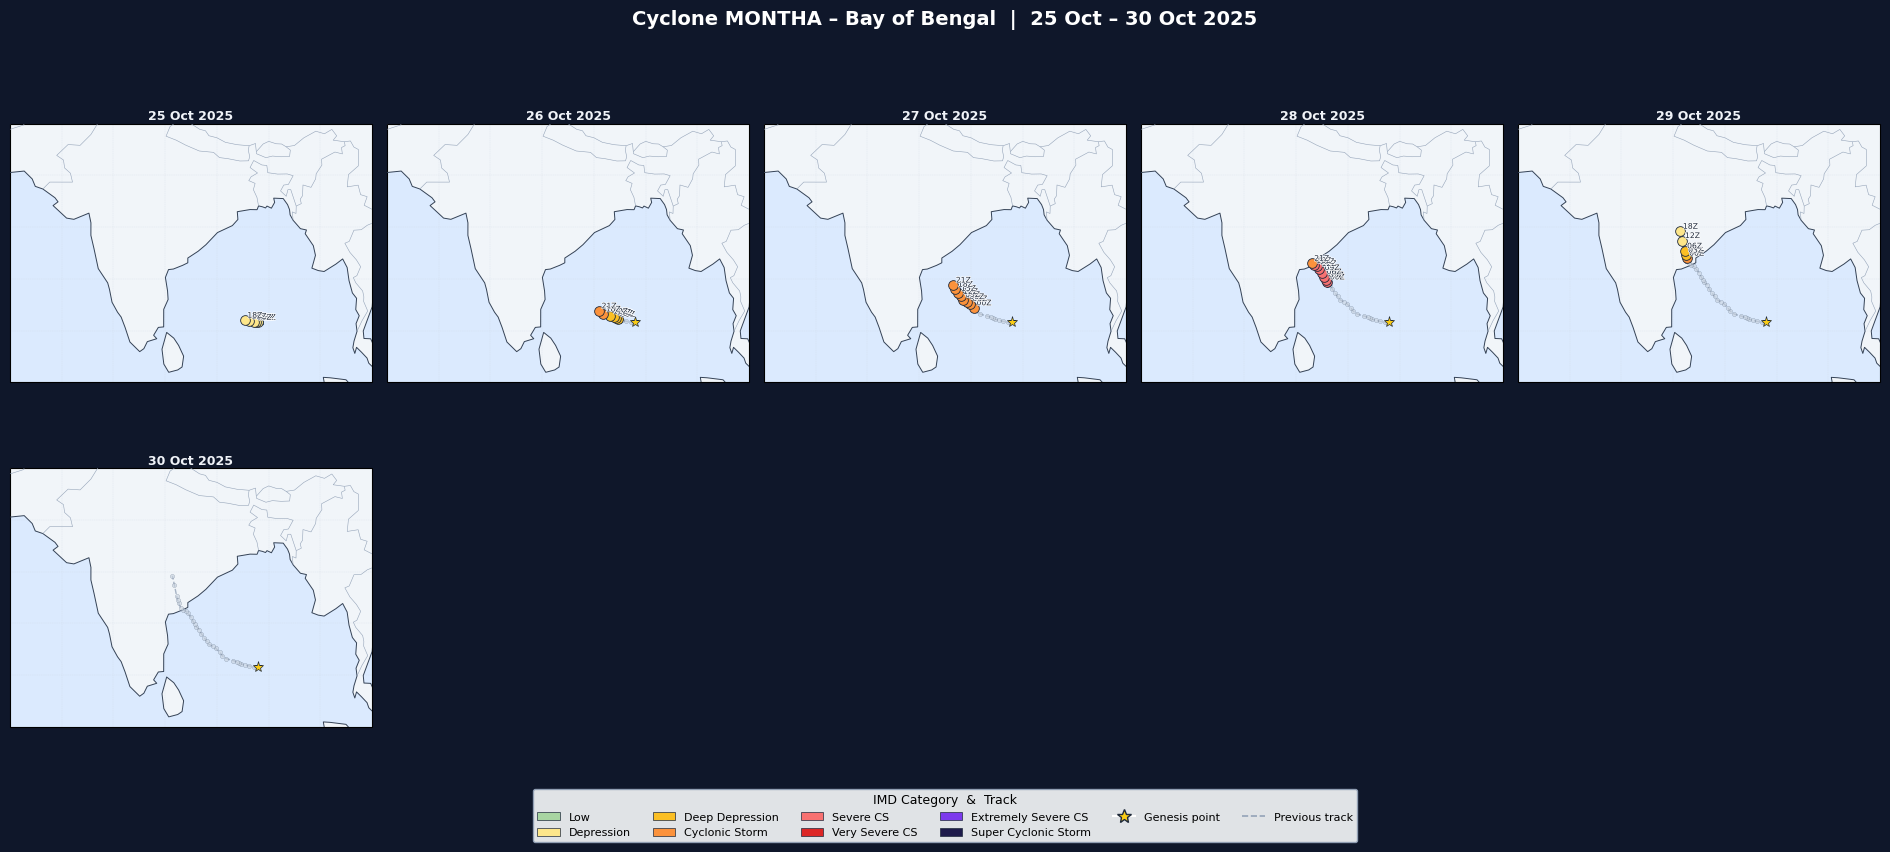

In [11]:
"""
=============================================================================
Cyclone MONTHA – Daily Track Maps  |  Cumulative Track + Configurable Range
=============================================================================
Each subplot shows:
  - Indian region map (coastlines + India shapefile)
  - CUMULATIVE track line from genesis up to that day (grows day by day)
  - Today's centres as bold dots joined with arrows
  - Previous days' centres as faint dots (historical positions)
  - Modular overlay system for wind / precip / MJO / second system

REQUIREMENTS:
    pip install matplotlib cartopy geopandas pandas openpyxl numpy

=============================================================================
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import geopandas as gpd
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings("ignore")


# =============================================================================
# ── USER CONFIGURATION  (edit only this section) ─────────────────────────────
# =============================================================================

EXCEL_FILE    = r"D:\PHD 2025~\LOW PRESSURE TRACKS\SCS_Montha_Oct_2025.xlsx"   # <-- your Excel file
SHAPEFILE_PATH = r"D:\PHD 2025~\PHD\Shapefiles\India Shapefile With Kashmir\India Shape\india_st.shp"

# ── DATE RANGE ───────────────────────────────────────────────────────────────
# Format: "DD-MM-YYYY"
START_DATE = "25-10-2025"
END_DATE   = "30-10-2025"

# ── LAYOUT ───────────────────────────────────────────────────────────────────
# Fewer columns = bigger subplots
#   7 → compact (31 days)  |  5 → medium  |  4 → large  |  3 → very large
NCOLS = 5

# ── SUBPLOT SIZE ─────────────────────────────────────────────────────────────
# "small"  : 2.6 / 3.0   "medium" : 3.8 / 4.2
# "large"  : 5.0 / 5.5   "xlarge" : 6.5 / 7.0
PLOT_WIDTH_PER_COL  = 3.8
PLOT_HEIGHT_PER_ROW = 4.2

# ── MAP DOMAIN  [lon_min, lon_max, lat_min, lat_max] ─────────────────────────
MAP_EXTENT = [65, 100, 5, 30]

# ── CUMULATIVE TRACK STYLE ───────────────────────────────────────────────────
CUMUL_LINE_COLOR     = "#94a3b8"   # colour of the historical track line
CUMUL_LINE_WIDTH     = 1.0         # line thickness
CUMUL_LINE_STYLE     = "--"        # "--" dashed  |  "-" solid  |  ":"  dotted
CUMUL_DOT_COLOR      = "#cbd5e1"   # colour of past centre dots
CUMUL_DOT_SIZE       = 3           # size of past centre dots (smaller than today)
CUMUL_DOT_ALPHA      = 0.6         # transparency of past dots

# ── OUTPUT ───────────────────────────────────────────────────────────────────
OUTPUT_FILE          = "cyclone_montha_october2025.png"
OUTPUT_DPI           = 180
SAVE_INDIVIDUAL_DAYS = False


# =============================================================================
# ── CATEGORY COLOUR MAP (IMD scale) ──────────────────────────────────────────
# =============================================================================

CATEGORY_COLORS = {
    "L"   : "#a8d5a2",
    "D"   : "#fde68a",
    "DD"  : "#fbbf24",
    "CS"  : "#fb923c",
    "SCS" : "#f87171",
    "VSCS": "#dc2626",
    "ESCS": "#7c3aed",
    "SuCS": "#1e1b4b",
}
DEFAULT_COLOR = "#60a5fa"

CATEGORY_LABELS = {
    "L"   : "Low",
    "D"   : "Depression",
    "DD"  : "Deep Depression",
    "CS"  : "Cyclonic Storm",
    "SCS" : "Severe CS",
    "VSCS": "Very Severe CS",
    "ESCS": "Extremely Severe CS",
    "SuCS": "Super Cyclonic Storm",
}

def cat_color(cat):
    return CATEGORY_COLORS.get(str(cat).strip(), DEFAULT_COLOR)

def cat_label(cat):
    return CATEGORY_LABELS.get(str(cat).strip(), str(cat).strip())


# =============================================================================
# ── OVERLAY MODULE REGISTRY ───────────────────────────────────────────────────
# Each function signature: def my_overlay(ax, day_date, proj, **kwargs)
# Append your function to OVERLAY_MODULES to activate it.
# Pass data via overlay_kwargs dict in main().
# =============================================================================

OVERLAY_MODULES = []

# ── Precipitation overlay skeleton ───────────────────────────────────────────
# def overlay_precip(ax, day_date, proj, precip_ds=None, **kwargs):
#     if precip_ds is None: return
#     # time_idx = find_time_index(precip_ds, day_date)
#     # data = precip_ds["tp"][time_idx,:,:] * 1000
#     # cf = ax.contourf(lons, lats, data, levels=..., cmap="Blues",
#     #                  transform=proj, alpha=0.55, zorder=2)
# OVERLAY_MODULES.append(overlay_precip)

# ── MJO filtered signal overlay skeleton ─────────────────────────────────────
# def overlay_mjo(ax, day_date, proj, mjo_ds=None, **kwargs):
#     if mjo_ds is None: return
#     # data = mjo_ds["tp_mjo"][:, :, time_idx] * 1000   # shape: lat, lon
#     # cf = ax.contourf(lons, lats, data, levels=np.linspace(-10,10,21),
#     #                  cmap="RdBu_r", transform=proj, alpha=0.55, zorder=2)
# OVERLAY_MODULES.append(overlay_mjo)

# ── Wind overlay skeleton ─────────────────────────────────────────────────────
# def overlay_wind(ax, day_date, proj, wind_ds=None, **kwargs):
#     if wind_ds is None: return
#     # ax.quiver(lons[::4], lats[::4], u[::4,::4], v[::4,::4],
#     #           transform=proj, zorder=6, scale=200, width=0.003)
# OVERLAY_MODULES.append(overlay_wind)

# ── Second low pressure system skeleton ──────────────────────────────────────
# def overlay_second_system(ax, day_date, proj,
#                            second_track_df=None, second_past_df=None, **kwargs):
#     """Second system also gets its own cumulative track."""
#     if second_track_df is None: return
#     # Past cumulative line
#     if second_past_df is not None and not second_past_df.empty:
#         ax.plot(second_past_df["lon"], second_past_df["lat"],
#                 CUMUL_LINE_STYLE, color="#c4b5fd",
#                 linewidth=CUMUL_LINE_WIDTH, transform=proj,
#                 zorder=6, alpha=0.7)
#         ax.plot(second_past_df["lon"], second_past_df["lat"],
#                 "o", color=CUMUL_DOT_COLOR, markersize=CUMUL_DOT_SIZE,
#                 transform=proj, zorder=6, alpha=CUMUL_DOT_ALPHA)
#     # Today
#     day_data = second_track_df[second_track_df["date"] == day_date]
#     if day_data.empty: return
#     lons, lats = day_data["lon"].values, day_data["lat"].values
#     if len(lons) > 1:
#         ax.plot(lons, lats, "-", color="#a78bfa", linewidth=1.2,
#                 transform=proj, zorder=7)
#     for lon, lat, hr in zip(lons, lats, day_data["hour"].values):
#         ax.plot(lon, lat, "s", color="#a78bfa", markersize=6,
#                 markeredgecolor="#1e293b", markeredgewidth=0.5,
#                 transform=proj, zorder=8)
#         ax.text(lon+0.25, lat+0.25, f"{int(hr):02d}Z", fontsize=5.5,
#                 color="#5b21b6", transform=proj, zorder=9,
#                 path_effects=[pe.withStroke(linewidth=1.0, foreground="white")])
# OVERLAY_MODULES.append(overlay_second_system)


# =============================================================================
# ── LOAD & CLEAN EXCEL ────────────────────────────────────────────────────────
# =============================================================================

def load_track(excel_path):
    df = pd.read_excel(excel_path, sheet_name="Sheet1")
    df = df[["Date", "Time (UTC)", "Lat (°N)", "Long (°E)",
             "ECP (hPa)", "ΔP (hPa)", "C.I. No.", "MSW (kt)", "Category"]].copy()
    df.columns = ["date_str", "time_utc", "lat", "lon",
                  "ecp", "delta_p", "ci", "msw", "category"]
    df = df.dropna(subset=["lat", "lon", "date_str"])
    df["date"]     = pd.to_datetime(df["date_str"], format="%d.%m.%Y").dt.date
    df["time_utc"] = pd.to_numeric(df["time_utc"], errors="coerce").fillna(0).astype(int)
    df["hour"]     = df["time_utc"] // 100
    df = df.sort_values(["date", "time_utc"]).reset_index(drop=True)
    return df


# =============================================================================
# ── DRAW ONE DAY'S SUBPLOT ────────────────────────────────────────────────────
# =============================================================================

def draw_day(ax, day_date, track_df, past_track_df, india_shp, proj,
             overlay_kwargs=None):
    """
    ax            : cartopy GeoAxes
    day_date      : date of this subplot
    track_df      : ALL track rows for today only
    past_track_df : ALL track rows strictly before today (cumulative history)
    india_shp     : GeoDataFrame of India boundary (or None)
    proj          : ccrs.PlateCarree()
    overlay_kwargs: dict passed to every overlay module
    """

    ax.set_extent(MAP_EXTENT, crs=proj)

    # ── Base map ──────────────────────────────────────────────────────────────
    ax.add_feature(cfeature.OCEAN.with_scale("110m"),
                   facecolor="#dbeafe", zorder=1)
    ax.add_feature(cfeature.LAND.with_scale("110m"),
                   facecolor="#f1f5f9", zorder=2)
    ax.add_feature(cfeature.COASTLINE.with_scale("110m"),
                   linewidth=0.7, edgecolor="#334155", zorder=3)
    ax.add_feature(cfeature.BORDERS.with_scale("110m"),
                   linewidth=0.4, edgecolor="#94a3b8", zorder=4)
    ax.gridlines(draw_labels=False, linewidth=0.3,
                 color="#cbd5e1", alpha=0.5, linestyle="--", zorder=2)

    if india_shp is not None:
        india_shp.boundary.plot(ax=ax, linewidth=0.8,
                                edgecolor="#1e293b", facecolor="none",
                                transform=proj, zorder=5)

    # ── Title (date) ──────────────────────────────────────────────────────────
    ax.set_title(day_date.strftime("%d %b %Y"), fontsize=9,
                 fontweight="bold", color="#f0f3f8", pad=3)

    # ── Overlay modules ───────────────────────────────────────────────────────
    if overlay_kwargs is None:
        overlay_kwargs = {}
    for module_fn in OVERLAY_MODULES:
        module_fn(ax, day_date, proj, **overlay_kwargs)

    # ── CUMULATIVE TRACK (all days before today) ──────────────────────────────
    if past_track_df is not None and not past_track_df.empty:
        p_lons = past_track_df["lon"].values
        p_lats = past_track_df["lat"].values

        # Dashed historical line connecting all past centres in order
        ax.plot(p_lons, p_lats,
                CUMUL_LINE_STYLE,
                color=CUMUL_LINE_COLOR,
                linewidth=CUMUL_LINE_WIDTH,
                transform=proj, zorder=6, alpha=0.8)

        # Small faint dots at each past centre
        ax.plot(p_lons, p_lats,
                "o",
                color=CUMUL_DOT_COLOR,
                markersize=CUMUL_DOT_SIZE,
                markeredgecolor="#64748b",
                markeredgewidth=0.3,
                transform=proj, zorder=6,
                alpha=CUMUL_DOT_ALPHA)

        # Mark the genesis point with a star
        ax.plot(p_lons[0], p_lats[0],
                "*",
                color="#facc15",
                markersize=8,
                markeredgecolor="#1e293b",
                markeredgewidth=0.5,
                transform=proj, zorder=9,
                label="Genesis")

    # ── TODAY'S TRACK (bold, coloured, with arrows) ───────────────────────────
    day_data = track_df[track_df["date"] == day_date]
    if day_data.empty:
        return

    lons  = day_data["lon"].values
    lats  = day_data["lat"].values
    cats  = day_data["category"].values
    hours = day_data["hour"].values

    # Solid line connecting today's centres
    if len(lons) > 1:
        ax.plot(lons, lats, "-", color="#1e3a5f", linewidth=1.4,
                transform=proj, zorder=7, alpha=0.95)

        # Direction arrows at midpoint of each today-segment
        for i in range(len(lons) - 1):
            dx    = lons[i+1] - lons[i]
            dy    = lats[i+1] - lats[i]
            mid_x = (lons[i] + lons[i+1]) / 2
            mid_y = (lats[i] + lats[i+1]) / 2
            ax.annotate("",
                xy        =(mid_x + dx * 0.01, mid_y + dy * 0.01),
                xytext    =(mid_x - dx * 0.01, mid_y - dy * 0.01),
                xycoords  =proj._as_mpl_transform(ax),
                textcoords=proj._as_mpl_transform(ax),
                arrowprops=dict(arrowstyle="-|>", color="#1e3a5f",
                                lw=1.0, mutation_scale=8),
                zorder=8)

    # Coloured dots for today's centres (bigger, category-coloured)
    for lon, lat, cat, hr in zip(lons, lats, cats, hours):
        ax.plot(lon, lat, "o",
                color=cat_color(cat),
                markersize=7,
                markeredgecolor="#1e293b",
                markeredgewidth=0.6,
                transform=proj, zorder=9)
        # Time label
        ax.text(lon + 0.25, lat + 0.25, f"{int(hr):02d}Z",
                fontsize=5.5, color="#1e293b",
                transform=proj, zorder=10,
                path_effects=[pe.withStroke(linewidth=1.0,
                                            foreground="white")])


# =============================================================================
# ── MAIN ─────────────────────────────────────────────────────────────────────
# =============================================================================

def main():

    proj = ccrs.PlateCarree()

    # Parse date range
    start     = datetime.strptime(START_DATE, "%d-%m-%Y").date()
    end       = datetime.strptime(END_DATE,   "%d-%m-%Y").date()
    date_list = [start + timedelta(days=i)
                 for i in range((end - start).days + 1)]
    n_days    = len(date_list)
    print(f"Date range : {start} → {end}  ({n_days} days)")

    # Load track
    print("Loading cyclone track data...")
    track_df = load_track(EXCEL_FILE)
    print(f"  → {len(track_df)} points  |  "
          f"{track_df['date'].min()} to {track_df['date'].max()}")

    # Load shapefile
    print("Loading India shapefile...")
    try:
        india_shp = gpd.read_file(SHAPEFILE_PATH).to_crs(epsg=4326)
        print(f"  → {len(india_shp)} features")
    except Exception as e:
        print(f"  ⚠ Shapefile skipped: {e}")
        india_shp = None

    # Grid
    ncols  = NCOLS
    nrows  = int(np.ceil(n_days / ncols))
    fig_w  = ncols * PLOT_WIDTH_PER_COL
    fig_h  = nrows * PLOT_HEIGHT_PER_ROW
    print(f"Grid       : {nrows} rows × {ncols} cols")
    print(f"Figure size: {fig_w:.1f} × {fig_h:.1f} inches")

    fig = plt.figure(figsize=(fig_w, fig_h), facecolor="#0f172a")
    fig.suptitle(
        f"Cyclone MONTHA – Bay of Bengal  |  "
        f"{start.strftime('%d %b')} – {end.strftime('%d %b %Y')}",
        fontsize=14, fontweight="bold", color="white",
        y=0.998, va="top"
    )

    # overlay_kwargs — populate when activating overlay modules
    overlay_kwargs = {}
    # import netCDF4 as nc
    # overlay_kwargs["precip_ds"]       = nc.Dataset(r"path\to\anomaly.nc")
    # overlay_kwargs["mjo_ds"]          = nc.Dataset(r"path\to\mjo_lanczos.nc")
    # overlay_kwargs["second_track_df"] = load_track(r"path\to\second.xlsx")

    for idx, day_date in enumerate(date_list):
        ax = fig.add_subplot(nrows, ncols, idx + 1, projection=proj)

        # Build cumulative past track: all rows strictly before today
        past_mask    = track_df["date"] < day_date
        past_track   = track_df[past_mask].copy() if past_mask.any() else None

        draw_day(ax, day_date, track_df, past_track,
                 india_shp, proj, overlay_kwargs=overlay_kwargs)

        if SAVE_INDIVIDUAL_DAYS:
            sf = plt.figure(figsize=(PLOT_WIDTH_PER_COL * 1.5,
                                     PLOT_HEIGHT_PER_ROW * 1.5))
            sa = sf.add_subplot(1, 1, 1, projection=proj)
            draw_day(sa, day_date, track_df, past_track,
                     india_shp, proj, overlay_kwargs=overlay_kwargs)
            sf.savefig(f"day_{day_date}.png", dpi=OUTPUT_DPI,
                       bbox_inches="tight")
            plt.close(sf)

    # Hide unused panels
    for idx in range(n_days, nrows * ncols):
        fig.add_subplot(nrows, ncols, idx + 1).set_visible(False)

    # Legend
    legend_handles = [
        mpatches.Patch(facecolor=color, edgecolor="#1e293b",
                       linewidth=0.5, label=cat_label(cat))
        for cat, color in CATEGORY_COLORS.items()
    ]
    # Add genesis star to legend
    legend_handles.append(
        plt.Line2D([0], [0], marker="*", color="w",
                   markerfacecolor="#facc15", markeredgecolor="#1e293b",
                   markersize=10, label="Genesis point")
    )
    # Add cumulative track line to legend
    legend_handles.append(
        plt.Line2D([0], [0], linestyle=CUMUL_LINE_STYLE,
                   color=CUMUL_LINE_COLOR, linewidth=1.2,
                   label="Previous track")
    )

    fig.legend(handles=legend_handles, loc="lower center",
               ncol=min(len(legend_handles), 6),
               fontsize=8, frameon=True, framealpha=0.9,
               facecolor="#f8fafc", edgecolor="#94a3b8",
               title="IMD Category  &  Track", title_fontsize=9,
               bbox_to_anchor=(0.5, 0.0))

    plt.tight_layout(rect=[0, 0.05, 1, 0.997])
    plt.savefig(OUTPUT_FILE, dpi=OUTPUT_DPI, bbox_inches="tight",
                facecolor=fig.get_facecolor())
    print(f"\n✅ Saved → {OUTPUT_FILE}")
    plt.show()


if __name__ == "__main__":
    main()


# 2. Arabian sea depression + Cyclone Montha =>

Date range : 2025-10-22 → 2025-10-31  (10 days)
Loading Cyclone Montha track data...
  → 32 points  |  2025-10-25 to 2025-10-29
Loading Arabian Sea Depression track data...
  → 50 points  |  2025-10-22 to 2025-10-31
Loading India shapefile...
  ⚠ Shapefile skipped: Cannot transform naive geometries.  Please set a crs on the object first.
Grid       : 2 rows × 5 cols
Figure size: 19.0 × 8.4 inches

✅ Saved → cyclone_montha_october2025.png


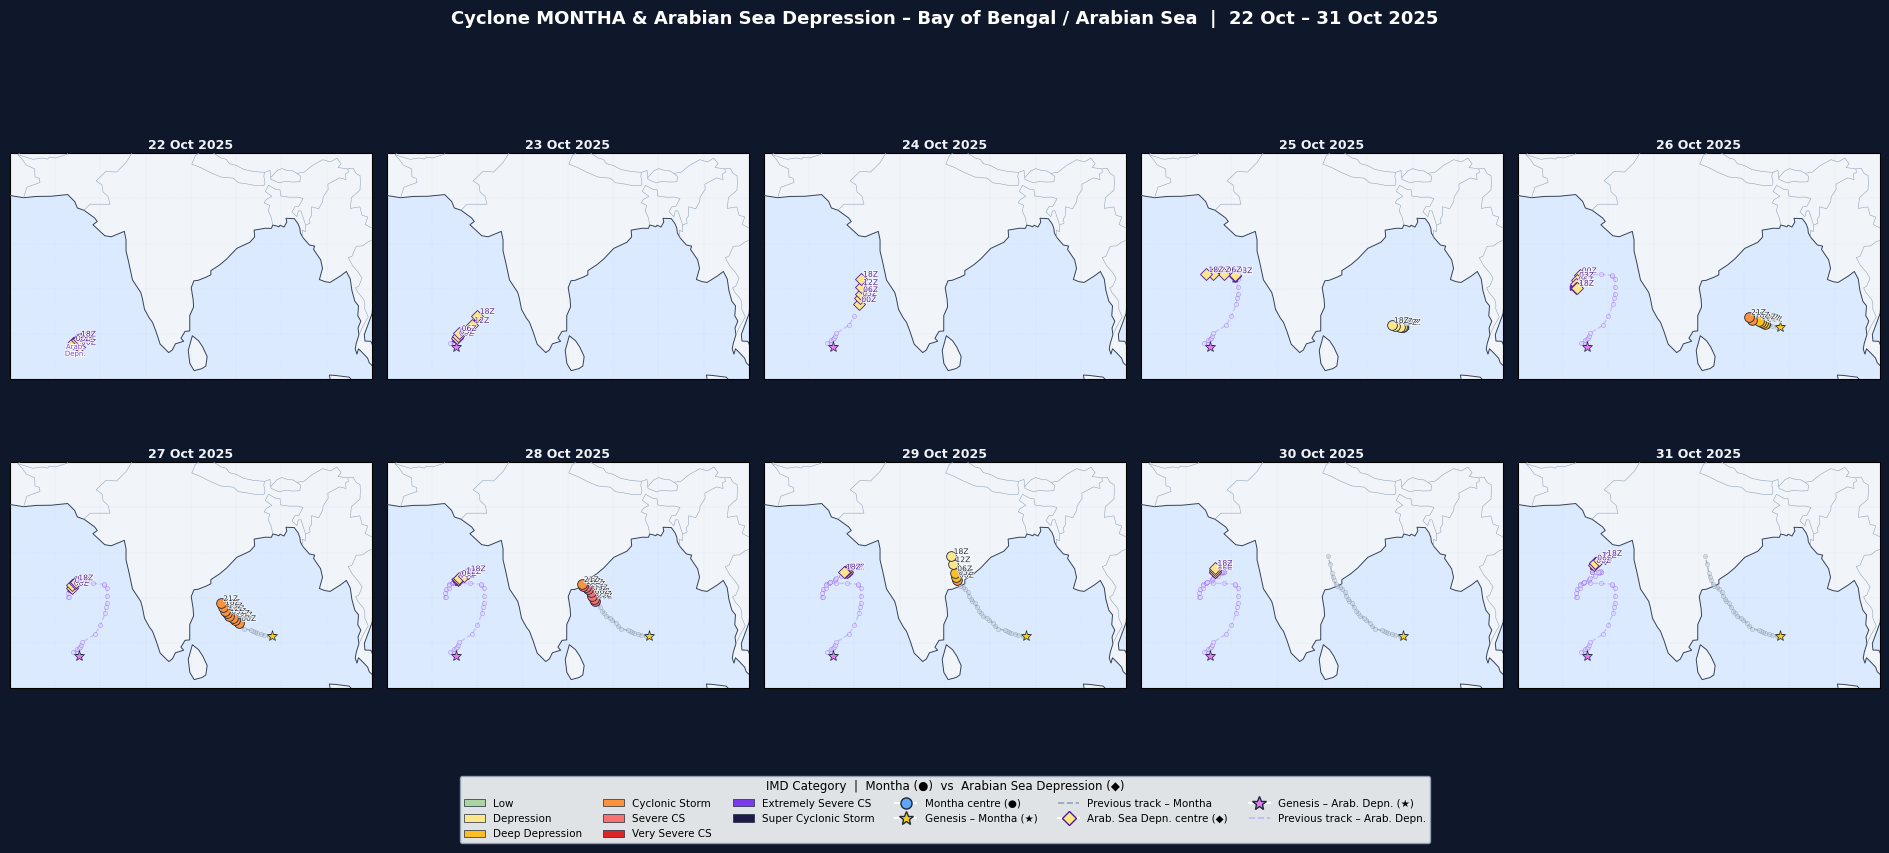

In [13]:
"""
=============================================================================
Cyclone MONTHA – Daily Track Maps  |  Cumulative Track + Configurable Range
=============================================================================
Each subplot shows:
  - Indian region map (coastlines + India shapefile)
  - CUMULATIVE track line from genesis up to that day (grows day by day)
  - Today's centres as bold dots joined with arrows
  - Previous days' centres as faint dots (historical positions)
  - Second system (Arabian Sea Depression) overlay with its own track

REQUIREMENTS:
    pip install matplotlib cartopy geopandas pandas openpyxl numpy

=============================================================================
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import geopandas as gpd
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings("ignore")


# =============================================================================
# ── USER CONFIGURATION  (edit only this section) ─────────────────────────────
# =============================================================================

EXCEL_FILE     = r"D:\PHD 2025~\LOW PRESSURE TRACKS\SCS_Montha_Oct_2025.xlsx"
EXCEL_FILE_2   = r"D:\PHD 2025~\LOW PRESSURE TRACKS\D_Arabian_Sea_Oct_2025.xlsx"  # <-- 2nd system
SHAPEFILE_PATH = r"D:\PHD 2025~\PHD\Shapefiles\India Shapefile With Kashmir\India Shape\india_st.shp"

# ── DATE RANGE ───────────────────────────────────────────────────────────────
START_DATE = "22-10-2025"   # widened to capture Arabian Sea depression genesis
END_DATE   = "31-10-2025"

# ── LAYOUT ───────────────────────────────────────────────────────────────────
NCOLS = 5

# ── SUBPLOT SIZE ─────────────────────────────────────────────────────────────
PLOT_WIDTH_PER_COL  = 3.8
PLOT_HEIGHT_PER_ROW = 4.2

# ── MAP DOMAIN  [lon_min, lon_max, lat_min, lat_max] ─────────────────────────
# Widened westward to capture the Arabian Sea depression (~67°E)
MAP_EXTENT = [60, 100, 5, 30]

# ── CUMULATIVE TRACK STYLE (Montha – primary) ─────────────────────────────────
CUMUL_LINE_COLOR     = "#94a3b8"
CUMUL_LINE_WIDTH     = 1.0
CUMUL_LINE_STYLE     = "--"
CUMUL_DOT_COLOR      = "#cbd5e1"
CUMUL_DOT_SIZE       = 3
CUMUL_DOT_ALPHA      = 0.6

# ── CUMULATIVE TRACK STYLE (Arabian Sea Depression – secondary) ───────────────
CUMUL2_LINE_COLOR    = "#c4b5fd"   # soft violet
CUMUL2_LINE_WIDTH    = 1.0
CUMUL2_LINE_STYLE    = "--"
CUMUL2_DOT_COLOR     = "#ddd6fe"
CUMUL2_DOT_SIZE      = 3
CUMUL2_DOT_ALPHA     = 0.6

# ── OUTPUT ───────────────────────────────────────────────────────────────────
OUTPUT_FILE          = "cyclone_montha_october2025.png"
OUTPUT_DPI           = 180
SAVE_INDIVIDUAL_DAYS = False


# =============================================================================
# ── CATEGORY COLOUR MAP (IMD scale) ──────────────────────────────────────────
# =============================================================================

CATEGORY_COLORS = {
    "L"   : "#a8d5a2",
    "D"   : "#fde68a",
    "DD"  : "#fbbf24",
    "CS"  : "#fb923c",
    "SCS" : "#f87171",
    "VSCS": "#dc2626",
    "ESCS": "#7c3aed",
    "SuCS": "#1e1b4b",
}
DEFAULT_COLOR = "#60a5fa"

CATEGORY_LABELS = {
    "L"   : "Low",
    "D"   : "Depression",
    "DD"  : "Deep Depression",
    "CS"  : "Cyclonic Storm",
    "SCS" : "Severe CS",
    "VSCS": "Very Severe CS",
    "ESCS": "Extremely Severe CS",
    "SuCS": "Super Cyclonic Storm",
}

def cat_color(cat):
    return CATEGORY_COLORS.get(str(cat).strip(), DEFAULT_COLOR)

def cat_label(cat):
    return CATEGORY_LABELS.get(str(cat).strip(), str(cat).strip())


# =============================================================================
# ── OVERLAY MODULE REGISTRY ───────────────────────────────────────────────────
# =============================================================================

OVERLAY_MODULES = []

# =============================================================================
# ── SECOND SYSTEM OVERLAY  (Arabian Sea Depression) ──────────────────────────
# =============================================================================

def overlay_second_system(ax, day_date, proj,
                           second_track_df=None, **kwargs):
    """
    Plots the Arabian Sea Depression track on the same subplot.
      - Cumulative dashed line + faint dots for all days before today
      - Bold coloured dots + time labels for today
      - Genesis star if the system started before or on today
    Uses a violet colour palette to distinguish from Montha (blue/grey).
    """
    if second_track_df is None or second_track_df.empty:
        return

    # ── Cumulative past track ─────────────────────────────────────────────────
    past = second_track_df[second_track_df["date"] < day_date]
    if not past.empty:
        p_lons = past["lon"].values
        p_lats = past["lat"].values

        ax.plot(p_lons, p_lats,
                CUMUL2_LINE_STYLE,
                color=CUMUL2_LINE_COLOR,
                linewidth=CUMUL2_LINE_WIDTH,
                transform=proj, zorder=6, alpha=0.8)

        ax.plot(p_lons, p_lats,
                "o",
                color=CUMUL2_DOT_COLOR,
                markersize=CUMUL2_DOT_SIZE,
                markeredgecolor="#7c3aed",
                markeredgewidth=0.3,
                transform=proj, zorder=6,
                alpha=CUMUL2_DOT_ALPHA)

        # Genesis star for second system
        ax.plot(p_lons[0], p_lats[0],
                "*",
                color="#e879f9",        # fuchsia – distinct from Montha's yellow
                markersize=8,
                markeredgecolor="#1e293b",
                markeredgewidth=0.5,
                transform=proj, zorder=9)

    # ── Today's positions ─────────────────────────────────────────────────────
    day_data = second_track_df[second_track_df["date"] == day_date]
    if day_data.empty:
        return

    lons  = day_data["lon"].values
    lats  = day_data["lat"].values
    cats  = day_data["category"].values
    hours = day_data["hour"].values

    # Connecting line for today
    if len(lons) > 1:
        ax.plot(lons, lats, "-", color="#6d28d9", linewidth=1.4,
                transform=proj, zorder=7, alpha=0.95)

        # Direction arrows
        for i in range(len(lons) - 1):
            dx    = lons[i+1] - lons[i]
            dy    = lats[i+1] - lats[i]
            mid_x = (lons[i] + lons[i+1]) / 2
            mid_y = (lats[i] + lats[i+1]) / 2
            ax.annotate("",
                xy        =(mid_x + dx * 0.01, mid_y + dy * 0.01),
                xytext    =(mid_x - dx * 0.01, mid_y - dy * 0.01),
                xycoords  =proj._as_mpl_transform(ax),
                textcoords=proj._as_mpl_transform(ax),
                arrowprops=dict(arrowstyle="-|>", color="#6d28d9",
                                lw=1.0, mutation_scale=8),
                zorder=8)

    # Coloured diamond markers (square rotated) for the 2nd system
    for lon, lat, cat, hr in zip(lons, lats, cats, hours):
        ax.plot(lon, lat, "D",              # diamond marker → visually distinct
                color=cat_color(cat),
                markersize=6,
                markeredgecolor="#4c1d95",
                markeredgewidth=0.6,
                transform=proj, zorder=9)
        ax.text(lon + 0.25, lat + 0.25, f"{int(hr):02d}Z",
                fontsize=5.5, color="#4c1d95",
                transform=proj, zorder=10,
                path_effects=[pe.withStroke(linewidth=1.0,
                                            foreground="white")])

    # Label the system name on the FIRST day it appears
    first_date = second_track_df["date"].min()
    if day_date == first_date and len(lons) > 0:
        ax.text(lons[0] - 0.4, lats[0] - 1.0,
                "Arab.\nDepn.", fontsize=5, color="#7c3aed",
                ha="center", transform=proj, zorder=11,
                path_effects=[pe.withStroke(linewidth=1.2,
                                            foreground="white")])


# Register the overlay
OVERLAY_MODULES.append(overlay_second_system)


# =============================================================================
# ── LOAD & CLEAN EXCEL ────────────────────────────────────────────────────────
# =============================================================================

def load_track(excel_path):
    df = pd.read_excel(excel_path, sheet_name="Sheet1")
    df = df[["Date", "Time (UTC)", "Lat (°N)", "Long (°E)",
             "ECP (hPa)", "ΔP (hPa)", "C.I. No.", "MSW (kt)", "Category"]].copy()
    df.columns = ["date_str", "time_utc", "lat", "lon",
                  "ecp", "delta_p", "ci", "msw", "category"]
    df = df.dropna(subset=["lat", "lon", "date_str"])
    df["date"]     = pd.to_datetime(df["date_str"], format="%d.%m.%Y").dt.date
    df["time_utc"] = pd.to_numeric(df["time_utc"], errors="coerce").fillna(0).astype(int)
    df["hour"]     = df["time_utc"] // 100
    df = df.sort_values(["date", "time_utc"]).reset_index(drop=True)
    return df


# =============================================================================
# ── DRAW ONE DAY'S SUBPLOT ────────────────────────────────────────────────────
# =============================================================================

def draw_day(ax, day_date, track_df, past_track_df, india_shp, proj,
             overlay_kwargs=None):
    """
    ax            : cartopy GeoAxes
    day_date      : date of this subplot
    track_df      : ALL track rows for today only
    past_track_df : ALL track rows strictly before today (cumulative history)
    india_shp     : GeoDataFrame of India boundary (or None)
    proj          : ccrs.PlateCarree()
    overlay_kwargs: dict passed to every overlay module
    """

    ax.set_extent(MAP_EXTENT, crs=proj)

    # ── Base map ──────────────────────────────────────────────────────────────
    ax.add_feature(cfeature.OCEAN.with_scale("110m"),
                   facecolor="#dbeafe", zorder=1)
    ax.add_feature(cfeature.LAND.with_scale("110m"),
                   facecolor="#f1f5f9", zorder=2)
    ax.add_feature(cfeature.COASTLINE.with_scale("110m"),
                   linewidth=0.7, edgecolor="#334155", zorder=3)
    ax.add_feature(cfeature.BORDERS.with_scale("110m"),
                   linewidth=0.4, edgecolor="#94a3b8", zorder=4)
    ax.gridlines(draw_labels=False, linewidth=0.3,
                 color="#cbd5e1", alpha=0.5, linestyle="--", zorder=2)

    if india_shp is not None:
        india_shp.boundary.plot(ax=ax, linewidth=0.8,
                                edgecolor="#1e293b", facecolor="none",
                                transform=proj, zorder=5)

    # ── Title (date) ──────────────────────────────────────────────────────────
    ax.set_title(day_date.strftime("%d %b %Y"), fontsize=9,
                 fontweight="bold", color="#f0f3f8", pad=3)

    # ── Overlay modules (includes second system) ──────────────────────────────
    if overlay_kwargs is None:
        overlay_kwargs = {}
    for module_fn in OVERLAY_MODULES:
        module_fn(ax, day_date, proj, **overlay_kwargs)

    # ── CUMULATIVE TRACK – Montha (all days before today) ─────────────────────
    if past_track_df is not None and not past_track_df.empty:
        p_lons = past_track_df["lon"].values
        p_lats = past_track_df["lat"].values

        ax.plot(p_lons, p_lats,
                CUMUL_LINE_STYLE,
                color=CUMUL_LINE_COLOR,
                linewidth=CUMUL_LINE_WIDTH,
                transform=proj, zorder=6, alpha=0.8)

        ax.plot(p_lons, p_lats,
                "o",
                color=CUMUL_DOT_COLOR,
                markersize=CUMUL_DOT_SIZE,
                markeredgecolor="#64748b",
                markeredgewidth=0.3,
                transform=proj, zorder=6,
                alpha=CUMUL_DOT_ALPHA)

        # Genesis star – Montha
        ax.plot(p_lons[0], p_lats[0],
                "*",
                color="#facc15",
                markersize=8,
                markeredgecolor="#1e293b",
                markeredgewidth=0.5,
                transform=proj, zorder=9,
                label="Genesis (Montha)")

    # ── TODAY'S TRACK – Montha ────────────────────────────────────────────────
    day_data = track_df[track_df["date"] == day_date]
    if day_data.empty:
        return

    lons  = day_data["lon"].values
    lats  = day_data["lat"].values
    cats  = day_data["category"].values
    hours = day_data["hour"].values

    if len(lons) > 1:
        ax.plot(lons, lats, "-", color="#1e3a5f", linewidth=1.4,
                transform=proj, zorder=7, alpha=0.95)

        for i in range(len(lons) - 1):
            dx    = lons[i+1] - lons[i]
            dy    = lats[i+1] - lats[i]
            mid_x = (lons[i] + lons[i+1]) / 2
            mid_y = (lats[i] + lats[i+1]) / 2
            ax.annotate("",
                xy        =(mid_x + dx * 0.01, mid_y + dy * 0.01),
                xytext    =(mid_x - dx * 0.01, mid_y - dy * 0.01),
                xycoords  =proj._as_mpl_transform(ax),
                textcoords=proj._as_mpl_transform(ax),
                arrowprops=dict(arrowstyle="-|>", color="#1e3a5f",
                                lw=1.0, mutation_scale=8),
                zorder=8)

    # Circle markers for Montha
    for lon, lat, cat, hr in zip(lons, lats, cats, hours):
        ax.plot(lon, lat, "o",
                color=cat_color(cat),
                markersize=7,
                markeredgecolor="#1e293b",
                markeredgewidth=0.6,
                transform=proj, zorder=9)
        ax.text(lon + 0.25, lat + 0.25, f"{int(hr):02d}Z",
                fontsize=5.5, color="#1e293b",
                transform=proj, zorder=10,
                path_effects=[pe.withStroke(linewidth=1.0,
                                            foreground="white")])


# =============================================================================
# ── MAIN ─────────────────────────────────────────────────────────────────────
# =============================================================================

def main():

    proj = ccrs.PlateCarree()

    # Parse date range
    start     = datetime.strptime(START_DATE, "%d-%m-%Y").date()
    end       = datetime.strptime(END_DATE,   "%d-%m-%Y").date()
    date_list = [start + timedelta(days=i)
                 for i in range((end - start).days + 1)]
    n_days    = len(date_list)
    print(f"Date range : {start} → {end}  ({n_days} days)")

    # Load Montha track
    print("Loading Cyclone Montha track data...")
    track_df = load_track(EXCEL_FILE)
    print(f"  → {len(track_df)} points  |  "
          f"{track_df['date'].min()} to {track_df['date'].max()}")

    # Load Arabian Sea Depression track
    print("Loading Arabian Sea Depression track data...")
    try:
        track_df2 = load_track(EXCEL_FILE_2)
        print(f"  → {len(track_df2)} points  |  "
              f"{track_df2['date'].min()} to {track_df2['date'].max()}")
    except Exception as e:
        print(f"  ⚠ Second system data skipped: {e}")
        track_df2 = None

    # Load shapefile
    print("Loading India shapefile...")
    try:
        india_shp = gpd.read_file(SHAPEFILE_PATH).to_crs(epsg=4326)
        print(f"  → {len(india_shp)} features")
    except Exception as e:
        print(f"  ⚠ Shapefile skipped: {e}")
        india_shp = None

    # Grid
    ncols  = NCOLS
    nrows  = int(np.ceil(n_days / ncols))
    fig_w  = ncols * PLOT_WIDTH_PER_COL
    fig_h  = nrows * PLOT_HEIGHT_PER_ROW
    print(f"Grid       : {nrows} rows × {ncols} cols")
    print(f"Figure size: {fig_w:.1f} × {fig_h:.1f} inches")

    fig = plt.figure(figsize=(fig_w, fig_h), facecolor="#0f172a")
    fig.suptitle(
        f"Cyclone MONTHA & Arabian Sea Depression – Bay of Bengal / Arabian Sea  |  "
        f"{start.strftime('%d %b')} – {end.strftime('%d %b %Y')}",
        fontsize=13, fontweight="bold", color="white",
        y=0.998, va="top"
    )

    # Pass second system dataframe into every overlay call via overlay_kwargs
    overlay_kwargs = {
        "second_track_df": track_df2,
    }

    for idx, day_date in enumerate(date_list):
        ax = fig.add_subplot(nrows, ncols, idx + 1, projection=proj)

        # Cumulative past track for Montha
        past_mask  = track_df["date"] < day_date
        past_track = track_df[past_mask].copy() if past_mask.any() else None

        draw_day(ax, day_date, track_df, past_track,
                 india_shp, proj, overlay_kwargs=overlay_kwargs)

        if SAVE_INDIVIDUAL_DAYS:
            sf = plt.figure(figsize=(PLOT_WIDTH_PER_COL * 1.5,
                                     PLOT_HEIGHT_PER_ROW * 1.5))
            sa = sf.add_subplot(1, 1, 1, projection=proj)
            draw_day(sa, day_date, track_df, past_track,
                     india_shp, proj, overlay_kwargs=overlay_kwargs)
            sf.savefig(f"day_{day_date}.png", dpi=OUTPUT_DPI,
                       bbox_inches="tight")
            plt.close(sf)

    # Hide unused panels
    for idx in range(n_days, nrows * ncols):
        fig.add_subplot(nrows, ncols, idx + 1).set_visible(False)

    # ── Legend ────────────────────────────────────────────────────────────────
    legend_handles = [
        mpatches.Patch(facecolor=color, edgecolor="#1e293b",
                       linewidth=0.5, label=cat_label(cat))
        for cat, color in CATEGORY_COLORS.items()
    ]

    # Montha track elements
    legend_handles.append(
        plt.Line2D([0], [0], marker="o", color="w",
                   markerfacecolor="#60a5fa", markeredgecolor="#1e293b",
                   markersize=8, label="Montha centre (●)")
    )
    legend_handles.append(
        plt.Line2D([0], [0], marker="*", color="w",
                   markerfacecolor="#facc15", markeredgecolor="#1e293b",
                   markersize=10, label="Genesis – Montha (★)")
    )
    legend_handles.append(
        plt.Line2D([0], [0], linestyle=CUMUL_LINE_STYLE,
                   color=CUMUL_LINE_COLOR, linewidth=1.2,
                   label="Previous track – Montha")
    )

    # Arabian Sea Depression elements
    legend_handles.append(
        plt.Line2D([0], [0], marker="D", color="w",
                   markerfacecolor="#fde68a", markeredgecolor="#4c1d95",
                   markersize=7, label="Arab. Sea Depn. centre (◆)")
    )
    legend_handles.append(
        plt.Line2D([0], [0], marker="*", color="w",
                   markerfacecolor="#e879f9", markeredgecolor="#1e293b",
                   markersize=10, label="Genesis – Arab. Depn. (★)")
    )
    legend_handles.append(
        plt.Line2D([0], [0], linestyle=CUMUL2_LINE_STYLE,
                   color=CUMUL2_LINE_COLOR, linewidth=1.2,
                   label="Previous track – Arab. Depn.")
    )

    fig.legend(handles=legend_handles, loc="lower center",
               ncol=min(len(legend_handles), 6),
               fontsize=7.5, frameon=True, framealpha=0.9,
               facecolor="#f8fafc", edgecolor="#94a3b8",
               title="IMD Category  |  Montha (●)  vs  Arabian Sea Depression (◆)",
               title_fontsize=8.5,
               bbox_to_anchor=(0.5, 0.0))

    plt.tight_layout(rect=[0, 0.06, 1, 0.997])
    plt.savefig(OUTPUT_FILE, dpi=OUTPUT_DPI, bbox_inches="tight",
                facecolor=fig.get_facecolor())
    print(f"\n✅ Saved → {OUTPUT_FILE}")
    plt.show()


if __name__ == "__main__":
    main()

# 3. Two cyclones with 250 km radious =>

Date range : 2025-10-22 → 2025-10-30  (9 days)
Loading Cyclone Montha track data...
  → 32 points  |  2025-10-25 to 2025-10-29
Loading Arabian Sea Depression track data...
  → 50 points  |  2025-10-22 to 2025-10-31
Loading India shapefile...
  ⚠ Shapefile skipped: Cannot transform naive geometries.  Please set a crs on the object first.
Grid       : 2 rows × 5 cols
Figure size: 19.0 × 8.4 inches

✅ Saved → cyclone_montha_october2025.png


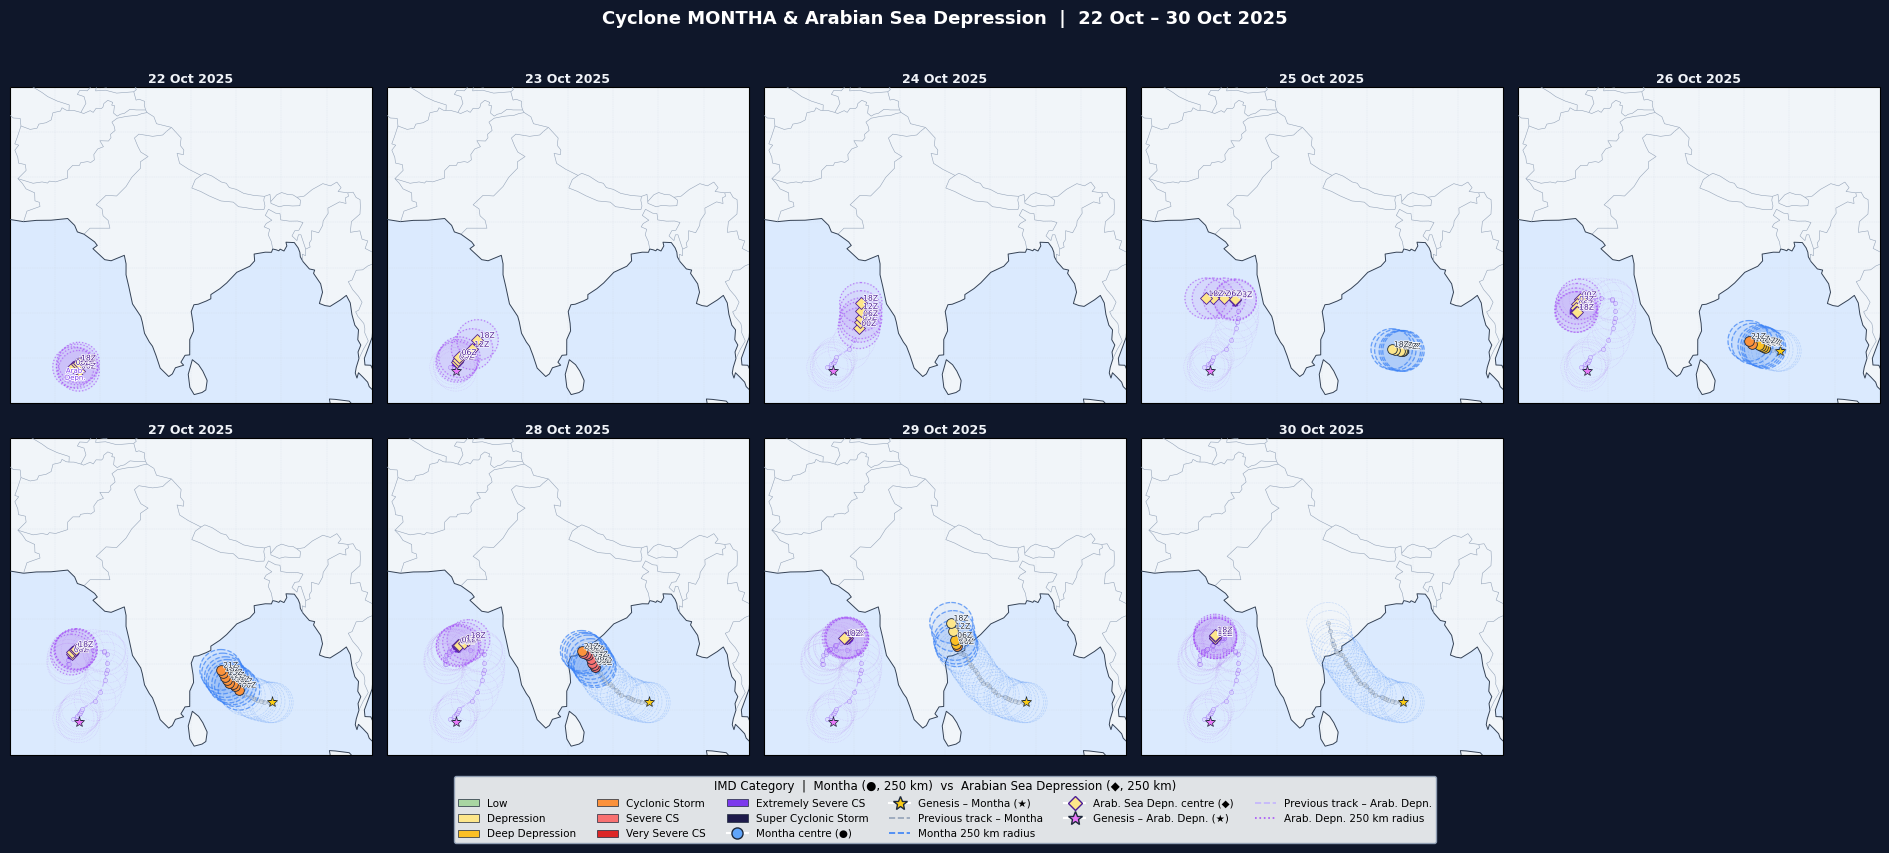

In [ ]:
"""
=============================================================================
Cyclone MONTHA – Daily Track Maps  |  Cumulative Track + Configurable Range
=============================================================================
Each subplot shows:
  - Indian region map (coastlines + India shapefile)
  - CUMULATIVE track line from genesis up to that day (grows day by day)
  - Today's centres as bold dots joined with arrows
  - Previous days' centres as faint dots (historical positions)
  - Second system (Arabian Sea Depression) overlay with its own track
  - Radius circles around each centre point for both systems

REQUIREMENTS:
    pip install matplotlib cartopy geopandas pandas openpyxl numpy

=============================================================================
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import geopandas as gpd
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings("ignore")


# =============================================================================
# ── USER CONFIGURATION  (edit only this section) ─────────────────────────────
# =============================================================================

EXCEL_FILE     = r"D:\PHD 2025~\LOW PRESSURE TRACKS\SCS_Montha_Oct_2025.xlsx"
EXCEL_FILE_2   = r"D:\PHD 2025~\LOW PRESSURE TRACKS\D_Arabian_Sea_Oct_2025.xlsx"
SHAPEFILE_PATH = r"D:\PHD 2025~\PHD\Shapefiles\India Shapefile With Kashmir\India Shape\india_st.shp"

# ── DATE RANGE ───────────────────────────────────────────────────────────────
START_DATE = "22-10-2025"
END_DATE   = "30-10-2025"

# ── LAYOUT ───────────────────────────────────────────────────────────────────
NCOLS = 5

# ── SUBPLOT SIZE ─────────────────────────────────────────────────────────────
PLOT_WIDTH_PER_COL  = 3.8
PLOT_HEIGHT_PER_ROW = 4.2

# ── MAP DOMAIN  [lon_min, lon_max, lat_min, lat_max] ─────────────────────────
MAP_EXTENT = [60, 100, 5, 40]

# ── CUMULATIVE TRACK STYLE (Montha – primary) ─────────────────────────────────
CUMUL_LINE_COLOR     = "#94a3b8"
CUMUL_LINE_WIDTH     = 1.0
CUMUL_LINE_STYLE     = "--"
CUMUL_DOT_COLOR      = "#cbd5e1"
CUMUL_DOT_SIZE       = 3
CUMUL_DOT_ALPHA      = 0.6

# ── CUMULATIVE TRACK STYLE (Arabian Sea Depression – secondary) ───────────────
CUMUL2_LINE_COLOR    = "#c4b5fd"
CUMUL2_LINE_WIDTH    = 1.0
CUMUL2_LINE_STYLE    = "--"
CUMUL2_DOT_COLOR     = "#ddd6fe"
CUMUL2_DOT_SIZE      = 3
CUMUL2_DOT_ALPHA     = 0.6


# =============================================================================
# ── RADIUS CIRCLE CONFIGURATION ──────────────────────────────────────────────
#
# HOW TO CUSTOMISE:
#   RADIUS_KM         : radius in kilometres  (e.g. 250, 500, 100)
#   CIRCLE_COLOR      : any hex, named colour, or rgba string
#                         e.g. "#f87171"  |  "red"  |  (1,0,0,0.3)
#   CIRCLE_LINEWIDTH  : stroke thickness in points  (0.5 = hair, 2.0 = bold)
#   CIRCLE_LINESTYLE  : "-"  solid  |  "--"  dashed  |  ":"  dotted  |  "-."  dash-dot
#   CIRCLE_ALPHA      : 0.0 (invisible) → 1.0 (fully opaque)
#   CIRCLE_FILL_COLOR : interior fill colour; set to "none" to disable fill
#   CIRCLE_FILL_ALPHA : opacity of the filled interior  (0.0 = transparent)
#   DRAW_RADIUS_CIRCLE: True to show circles | False to hide completely
#
# TWO INDEPENDENT SETS — one for Montha, one for Arabian Sea Depression.
# =============================================================================

# ── Montha radius circles ─────────────────────────────────────────────────────
MONTHA_RADIUS_KM         = 250        # <-- change radius here (km)
MONTHA_CIRCLE_COLOR      = "#3b82f6"  # blue stroke
MONTHA_CIRCLE_LINEWIDTH  = 0.9        # stroke width (pts)
MONTHA_CIRCLE_LINESTYLE  = "--"       # dashed ring
MONTHA_CIRCLE_ALPHA      = 0.70       # stroke opacity
MONTHA_CIRCLE_FILL_COLOR = "#3b82f6"  # fill colour (set "none" to disable)
MONTHA_CIRCLE_FILL_ALPHA = 0.06       # very light fill
MONTHA_DRAW_CIRCLE       = True       # set False to turn off completely

# ── Arabian Sea Depression radius circles ─────────────────────────────────────
ARAB_RADIUS_KM           = 250        # <-- change radius here (km)
ARAB_CIRCLE_COLOR        = "#a855f7"  # violet stroke
ARAB_CIRCLE_LINEWIDTH    = 0.9
ARAB_CIRCLE_LINESTYLE    = ":"        # dotted ring  ← different style on purpose
ARAB_CIRCLE_ALPHA        = 0.70
ARAB_CIRCLE_FILL_COLOR   = "#a855f7"
ARAB_CIRCLE_FILL_ALPHA   = 0.06
ARAB_DRAW_CIRCLE         = True


# ── OUTPUT ───────────────────────────────────────────────────────────────────
OUTPUT_FILE          = "cyclone_montha_october2025.png"
OUTPUT_DPI           = 180
SAVE_INDIVIDUAL_DAYS = False


# =============================================================================
# ── CATEGORY COLOUR MAP (IMD scale) ──────────────────────────────────────────
# =============================================================================

CATEGORY_COLORS = {
    "L"   : "#a8d5a2",
    "D"   : "#fde68a",
    "DD"  : "#fbbf24",
    "CS"  : "#fb923c",
    "SCS" : "#f87171",
    "VSCS": "#dc2626",
    "ESCS": "#7c3aed",
    "SuCS": "#1e1b4b",
}
DEFAULT_COLOR = "#60a5fa"

CATEGORY_LABELS = {
    "L"   : "Low",
    "D"   : "Depression",
    "DD"  : "Deep Depression",
    "CS"  : "Cyclonic Storm",
    "SCS" : "Severe CS",
    "VSCS": "Very Severe CS",
    "ESCS": "Extremely Severe CS",
    "SuCS": "Super Cyclonic Storm",
}

def cat_color(cat):
    return CATEGORY_COLORS.get(str(cat).strip(), DEFAULT_COLOR)

def cat_label(cat):
    return CATEGORY_LABELS.get(str(cat).strip(), str(cat).strip())


# =============================================================================
# ── HELPER: DRAW A RADIUS CIRCLE ON A CARTOPY AXES ───────────────────────────
#
# The Earth is curved, so we cannot simply offset lat/lon by a fixed degree
# value. Instead we compute N evenly-spaced points on a great-circle ring of
# the requested radius using the Haversine / inverse-Haversine formula, then
# plot those points as a closed polygon on the map.
#
# PARAMETERS
#   ax          : cartopy GeoAxes
#   centre_lon  : longitude of centre point (degrees)
#   centre_lat  : latitude  of centre point (degrees)
#   radius_km   : radius of the circle in kilometres
#   proj        : ccrs.PlateCarree()  (or your map projection)
#   color       : stroke colour
#   linewidth   : stroke thickness
#   linestyle   : "-"  "--"  ":"  "-."
#   alpha       : stroke opacity (0–1)
#   fill_color  : fill colour for the disk interior ("none" = no fill)
#   fill_alpha  : fill opacity (0–1); ignored when fill_color == "none"
#   n_pts       : number of vertices in the approximating polygon (default 180)
# =============================================================================

def draw_radius_circle(ax, centre_lon, centre_lat, radius_km, proj,
                       color="#3b82f6", linewidth=0.9, linestyle="--",
                       alpha=0.7, fill_color="none", fill_alpha=0.07,
                       n_pts=180):
    """
    Draw a geodesically correct circle of radius `radius_km` around
    (centre_lon, centre_lat) on a cartopy axes.
    """
    R_EARTH = 6371.0          # mean Earth radius in km
    d       = radius_km / R_EARTH   # angular distance in radians

    lat_r   = np.radians(centre_lat)
    lon_r   = np.radians(centre_lon)

    bearings = np.linspace(0, 2 * np.pi, n_pts, endpoint=False)

    ring_lats = np.degrees(
        np.arcsin(
            np.sin(lat_r) * np.cos(d) +
            np.cos(lat_r) * np.sin(d) * np.cos(bearings)
        )
    )
    ring_lons = centre_lon + np.degrees(
        np.arctan2(
            np.sin(bearings) * np.sin(d) * np.cos(lat_r),
            np.cos(d) - np.sin(lat_r) * np.sin(np.radians(ring_lats))
        )
    )

    # Close the ring
    ring_lons = np.append(ring_lons, ring_lons[0])
    ring_lats = np.append(ring_lats, ring_lats[0])

    # Fill (drawn first so the stroke sits on top)
    if fill_color != "none":
        ax.fill(ring_lons, ring_lats,
                color=fill_color, alpha=fill_alpha,
                transform=proj, zorder=7)

    # Stroke
    ax.plot(ring_lons, ring_lats,
            linestyle=linestyle,
            color=color,
            linewidth=linewidth,
            alpha=alpha,
            transform=proj,
            zorder=8)


# =============================================================================
# ── OVERLAY MODULE REGISTRY ───────────────────────────────────────────────────
# =============================================================================

OVERLAY_MODULES = []


# =============================================================================
# ── SECOND SYSTEM OVERLAY  (Arabian Sea Depression) ──────────────────────────
# =============================================================================

def overlay_second_system(ax, day_date, proj,
                           second_track_df=None, **kwargs):
    if second_track_df is None or second_track_df.empty:
        return

    # ── Cumulative past track ─────────────────────────────────────────────────
    past = second_track_df[second_track_df["date"] < day_date]
    if not past.empty:
        p_lons = past["lon"].values
        p_lats = past["lat"].values

        ax.plot(p_lons, p_lats,
                CUMUL2_LINE_STYLE, color=CUMUL2_LINE_COLOR,
                linewidth=CUMUL2_LINE_WIDTH,
                transform=proj, zorder=6, alpha=0.8)

        ax.plot(p_lons, p_lats, "o",
                color=CUMUL2_DOT_COLOR,
                markersize=CUMUL2_DOT_SIZE,
                markeredgecolor="#7c3aed", markeredgewidth=0.3,
                transform=proj, zorder=6, alpha=CUMUL2_DOT_ALPHA)

        # ── Radius circles on PAST centres (Arabian Sea Depression) ───────────
        if ARAB_DRAW_CIRCLE:
            for plon, plat in zip(p_lons, p_lats):
                draw_radius_circle(
                    ax, plon, plat, ARAB_RADIUS_KM, proj,
                    color=ARAB_CIRCLE_COLOR,
                    linewidth=max(0.3, ARAB_CIRCLE_LINEWIDTH * 0.5),  # thinner for past
                    linestyle=ARAB_CIRCLE_LINESTYLE,
                    alpha=ARAB_CIRCLE_ALPHA * 0.35,                   # more transparent
                    fill_color="none",                                 # no fill on past
                )

        # Genesis star
        ax.plot(p_lons[0], p_lats[0], "*",
                color="#e879f9", markersize=8,
                markeredgecolor="#1e293b", markeredgewidth=0.5,
                transform=proj, zorder=9)

    # ── Today's positions ─────────────────────────────────────────────────────
    day_data = second_track_df[second_track_df["date"] == day_date]
    if day_data.empty:
        return

    lons  = day_data["lon"].values
    lats  = day_data["lat"].values
    cats  = day_data["category"].values
    hours = day_data["hour"].values

    # ── Radius circles on TODAY'S centres (Arabian Sea Depression) ────────────
    if ARAB_DRAW_CIRCLE:
        for lon, lat in zip(lons, lats):
            draw_radius_circle(
                ax, lon, lat, ARAB_RADIUS_KM, proj,
                color=ARAB_CIRCLE_COLOR,
                linewidth=ARAB_CIRCLE_LINEWIDTH,
                linestyle=ARAB_CIRCLE_LINESTYLE,
                alpha=ARAB_CIRCLE_ALPHA,
                fill_color=ARAB_CIRCLE_FILL_COLOR,
                fill_alpha=ARAB_CIRCLE_FILL_ALPHA,
            )

    # Connecting line
    if len(lons) > 1:
        ax.plot(lons, lats, "-", color="#6d28d9", linewidth=1.4,
                transform=proj, zorder=7, alpha=0.95)
        for i in range(len(lons) - 1):
            dx    = lons[i+1] - lons[i]
            dy    = lats[i+1] - lats[i]
            mid_x = (lons[i] + lons[i+1]) / 2
            mid_y = (lats[i] + lats[i+1]) / 2
            ax.annotate("",
                xy        =(mid_x + dx * 0.01, mid_y + dy * 0.01),
                xytext    =(mid_x - dx * 0.01, mid_y - dy * 0.01),
                xycoords  =proj._as_mpl_transform(ax),
                textcoords=proj._as_mpl_transform(ax),
                arrowprops=dict(arrowstyle="-|>", color="#6d28d9",
                                lw=1.0, mutation_scale=8),
                zorder=8)

    # Diamond markers
    for lon, lat, cat, hr in zip(lons, lats, cats, hours):
        ax.plot(lon, lat, "D",
                color=cat_color(cat), markersize=6,
                markeredgecolor="#4c1d95", markeredgewidth=0.6,
                transform=proj, zorder=10)
        ax.text(lon + 0.25, lat + 0.25, f"{int(hr):02d}Z",
                fontsize=5.5, color="#4c1d95",
                transform=proj, zorder=11,
                path_effects=[pe.withStroke(linewidth=1.0,
                                            foreground="white")])

    # Label on first day
    first_date = second_track_df["date"].min()
    if day_date == first_date and len(lons) > 0:
        ax.text(lons[0] - 0.4, lats[0] - 1.0,
                "Arab.\nDepn.", fontsize=5, color="#7c3aed",
                ha="center", transform=proj, zorder=12,
                path_effects=[pe.withStroke(linewidth=1.2,
                                            foreground="white")])


OVERLAY_MODULES.append(overlay_second_system)


# =============================================================================
# ── LOAD & CLEAN EXCEL ────────────────────────────────────────────────────────
# =============================================================================

def load_track(excel_path):
    df = pd.read_excel(excel_path, sheet_name="Sheet1")
    df = df[["Date", "Time (UTC)", "Lat (°N)", "Long (°E)",
             "ECP (hPa)", "ΔP (hPa)", "C.I. No.", "MSW (kt)", "Category"]].copy()
    df.columns = ["date_str", "time_utc", "lat", "lon",
                  "ecp", "delta_p", "ci", "msw", "category"]
    df = df.dropna(subset=["lat", "lon", "date_str"])
    df["date"]     = pd.to_datetime(df["date_str"], format="%d.%m.%Y").dt.date
    df["time_utc"] = pd.to_numeric(df["time_utc"], errors="coerce").fillna(0).astype(int)
    df["hour"]     = df["time_utc"] // 100
    df = df.sort_values(["date", "time_utc"]).reset_index(drop=True)
    return df


# =============================================================================
# ── DRAW ONE DAY'S SUBPLOT ────────────────────────────────────────────────────
# =============================================================================

def draw_day(ax, day_date, track_df, past_track_df, india_shp, proj,
             overlay_kwargs=None):

    ax.set_extent(MAP_EXTENT, crs=proj)

    # ── Base map ──────────────────────────────────────────────────────────────
    ax.add_feature(cfeature.OCEAN.with_scale("110m"),
                   facecolor="#dbeafe", zorder=1)
    ax.add_feature(cfeature.LAND.with_scale("110m"),
                   facecolor="#f1f5f9", zorder=2)
    ax.add_feature(cfeature.COASTLINE.with_scale("110m"),
                   linewidth=0.7, edgecolor="#334155", zorder=3)
    ax.add_feature(cfeature.BORDERS.with_scale("110m"),
                   linewidth=0.4, edgecolor="#94a3b8", zorder=4)
    ax.gridlines(draw_labels=False, linewidth=0.3,
                 color="#cbd5e1", alpha=0.5, linestyle="--", zorder=2)

    if india_shp is not None:
        india_shp.boundary.plot(ax=ax, linewidth=0.8,
                                edgecolor="#1e293b", facecolor="none",
                                transform=proj, zorder=5)

    ax.set_title(day_date.strftime("%d %b %Y"), fontsize=9,
                 fontweight="bold", color="#f0f3f8", pad=3)

    # ── Overlay modules (includes second system + its circles) ────────────────
    if overlay_kwargs is None:
        overlay_kwargs = {}
    for module_fn in OVERLAY_MODULES:
        module_fn(ax, day_date, proj, **overlay_kwargs)

    # ── CUMULATIVE TRACK – Montha ─────────────────────────────────────────────
    if past_track_df is not None and not past_track_df.empty:
        p_lons = past_track_df["lon"].values
        p_lats = past_track_df["lat"].values

        ax.plot(p_lons, p_lats,
                CUMUL_LINE_STYLE, color=CUMUL_LINE_COLOR,
                linewidth=CUMUL_LINE_WIDTH,
                transform=proj, zorder=6, alpha=0.8)

        ax.plot(p_lons, p_lats, "o",
                color=CUMUL_DOT_COLOR, markersize=CUMUL_DOT_SIZE,
                markeredgecolor="#64748b", markeredgewidth=0.3,
                transform=proj, zorder=6, alpha=CUMUL_DOT_ALPHA)

        # ── Radius circles on PAST centres (Montha) ───────────────────────────
        if MONTHA_DRAW_CIRCLE:
            for plon, plat in zip(p_lons, p_lats):
                draw_radius_circle(
                    ax, plon, plat, MONTHA_RADIUS_KM, proj,
                    color=MONTHA_CIRCLE_COLOR,
                    linewidth=max(0.3, MONTHA_CIRCLE_LINEWIDTH * 0.5),
                    linestyle=MONTHA_CIRCLE_LINESTYLE,
                    alpha=MONTHA_CIRCLE_ALPHA * 0.35,
                    fill_color="none",
                )

        # Genesis star
        ax.plot(p_lons[0], p_lats[0], "*",
                color="#facc15", markersize=8,
                markeredgecolor="#1e293b", markeredgewidth=0.5,
                transform=proj, zorder=9)

    # ── TODAY'S TRACK – Montha ────────────────────────────────────────────────
    day_data = track_df[track_df["date"] == day_date]
    if day_data.empty:
        return

    lons  = day_data["lon"].values
    lats  = day_data["lat"].values
    cats  = day_data["category"].values
    hours = day_data["hour"].values

    # ── Radius circles on TODAY'S centres (Montha) ────────────────────────────
    if MONTHA_DRAW_CIRCLE:
        for lon, lat in zip(lons, lats):
            draw_radius_circle(
                ax, lon, lat, MONTHA_RADIUS_KM, proj,
                color=MONTHA_CIRCLE_COLOR,
                linewidth=MONTHA_CIRCLE_LINEWIDTH,
                linestyle=MONTHA_CIRCLE_LINESTYLE,
                alpha=MONTHA_CIRCLE_ALPHA,
                fill_color=MONTHA_CIRCLE_FILL_COLOR,
                fill_alpha=MONTHA_CIRCLE_FILL_ALPHA,
            )

    # Connecting line
    if len(lons) > 1:
        ax.plot(lons, lats, "-", color="#1e3a5f", linewidth=1.4,
                transform=proj, zorder=7, alpha=0.95)
        for i in range(len(lons) - 1):
            dx    = lons[i+1] - lons[i]
            dy    = lats[i+1] - lats[i]
            mid_x = (lons[i] + lons[i+1]) / 2
            mid_y = (lats[i] + lats[i+1]) / 2
            ax.annotate("",
                xy        =(mid_x + dx * 0.01, mid_y + dy * 0.01),
                xytext    =(mid_x - dx * 0.01, mid_y - dy * 0.01),
                xycoords  =proj._as_mpl_transform(ax),
                textcoords=proj._as_mpl_transform(ax),
                arrowprops=dict(arrowstyle="-|>", color="#1e3a5f",
                                lw=1.0, mutation_scale=8),
                zorder=8)

    # Circle markers for Montha
    for lon, lat, cat, hr in zip(lons, lats, cats, hours):
        ax.plot(lon, lat, "o",
                color=cat_color(cat), markersize=7,
                markeredgecolor="#1e293b", markeredgewidth=0.6,
                transform=proj, zorder=10)
        ax.text(lon + 0.25, lat + 0.25, f"{int(hr):02d}Z",
                fontsize=5.5, color="#1e293b",
                transform=proj, zorder=11,
                path_effects=[pe.withStroke(linewidth=1.0,
                                            foreground="white")])


# =============================================================================
# ── MAIN ─────────────────────────────────────────────────────────────────────
# =============================================================================

def main():

    proj = ccrs.PlateCarree()

    start     = datetime.strptime(START_DATE, "%d-%m-%Y").date()
    end       = datetime.strptime(END_DATE,   "%d-%m-%Y").date()
    date_list = [start + timedelta(days=i)
                 for i in range((end - start).days + 1)]
    n_days    = len(date_list)
    print(f"Date range : {start} → {end}  ({n_days} days)")

    print("Loading Cyclone Montha track data...")
    track_df = load_track(EXCEL_FILE)
    print(f"  → {len(track_df)} points  |  "
          f"{track_df['date'].min()} to {track_df['date'].max()}")

    print("Loading Arabian Sea Depression track data...")
    try:
        track_df2 = load_track(EXCEL_FILE_2)
        print(f"  → {len(track_df2)} points  |  "
              f"{track_df2['date'].min()} to {track_df2['date'].max()}")
    except Exception as e:
        print(f"  ⚠ Second system data skipped: {e}")
        track_df2 = None

    print("Loading India shapefile...")
    try:
        india_shp = gpd.read_file(SHAPEFILE_PATH).to_crs(epsg=4326)
        print(f"  → {len(india_shp)} features")
    except Exception as e:
        print(f"  ⚠ Shapefile skipped: {e}")
        india_shp = None

    ncols  = NCOLS
    nrows  = int(np.ceil(n_days / ncols))
    fig_w  = ncols * PLOT_WIDTH_PER_COL
    fig_h  = nrows * PLOT_HEIGHT_PER_ROW
    print(f"Grid       : {nrows} rows × {ncols} cols")
    print(f"Figure size: {fig_w:.1f} × {fig_h:.1f} inches")

    fig = plt.figure(figsize=(fig_w, fig_h), facecolor="#0f172a")
    fig.suptitle(
        f"Cyclone MONTHA & Arabian Sea Depression  |  "
        f"{start.strftime('%d %b')} – {end.strftime('%d %b %Y')}",
        fontsize=13, fontweight="bold", color="white",
        y=0.998, va="top"
    )

    overlay_kwargs = {"second_track_df": track_df2}

    for idx, day_date in enumerate(date_list):
        ax = fig.add_subplot(nrows, ncols, idx + 1, projection=proj)

        past_mask  = track_df["date"] < day_date
        past_track = track_df[past_mask].copy() if past_mask.any() else None

        draw_day(ax, day_date, track_df, past_track,
                 india_shp, proj, overlay_kwargs=overlay_kwargs)

        if SAVE_INDIVIDUAL_DAYS:
            sf = plt.figure(figsize=(PLOT_WIDTH_PER_COL * 1.5,
                                     PLOT_HEIGHT_PER_ROW * 1.5))
            sa = sf.add_subplot(1, 1, 1, projection=proj)
            draw_day(sa, day_date, track_df, past_track,
                     india_shp, proj, overlay_kwargs=overlay_kwargs)
            sf.savefig(f"day_{day_date}.png", dpi=OUTPUT_DPI,
                       bbox_inches="tight")
            plt.close(sf)

    for idx in range(n_days, nrows * ncols):
        fig.add_subplot(nrows, ncols, idx + 1).set_visible(False)

    # ── Legend ────────────────────────────────────────────────────────────────
    legend_handles = [
        mpatches.Patch(facecolor=color, edgecolor="#1e293b",
                       linewidth=0.5, label=cat_label(cat))
        for cat, color in CATEGORY_COLORS.items()
    ]

    legend_handles += [
        plt.Line2D([0], [0], marker="o", color="w",
                   markerfacecolor="#60a5fa", markeredgecolor="#1e293b",
                   markersize=8, label="Montha centre (●)"),
        plt.Line2D([0], [0], marker="*", color="w",
                   markerfacecolor="#facc15", markeredgecolor="#1e293b",
                   markersize=10, label="Genesis – Montha (★)"),
        plt.Line2D([0], [0], linestyle=CUMUL_LINE_STYLE,
                   color=CUMUL_LINE_COLOR, linewidth=1.2,
                   label="Previous track – Montha"),
        plt.Line2D([0], [0], linestyle=MONTHA_CIRCLE_LINESTYLE,
                   color=MONTHA_CIRCLE_COLOR, linewidth=1.2,
                   label=f"Montha {MONTHA_RADIUS_KM} km radius"),

        plt.Line2D([0], [0], marker="D", color="w",
                   markerfacecolor="#fde68a", markeredgecolor="#4c1d95",
                   markersize=7, label="Arab. Sea Depn. centre (◆)"),
        plt.Line2D([0], [0], marker="*", color="w",
                   markerfacecolor="#e879f9", markeredgecolor="#1e293b",
                   markersize=10, label="Genesis – Arab. Depn. (★)"),
        plt.Line2D([0], [0], linestyle=CUMUL2_LINE_STYLE,
                   color=CUMUL2_LINE_COLOR, linewidth=1.2,
                   label="Previous track – Arab. Depn."),
        plt.Line2D([0], [0], linestyle=ARAB_CIRCLE_LINESTYLE,
                   color=ARAB_CIRCLE_COLOR, linewidth=1.2,
                   label=f"Arab. Depn. {ARAB_RADIUS_KM} km radius"),
    ]

    fig.legend(handles=legend_handles, loc="lower center",
               ncol=min(len(legend_handles), 6),
               fontsize=7.5, frameon=True, framealpha=0.9,
               facecolor="#f8fafc", edgecolor="#94a3b8",
               title=f"IMD Category  |  Montha (●, {MONTHA_RADIUS_KM} km)  "
                     f"vs  Arabian Sea Depression (◆, {ARAB_RADIUS_KM} km)",
               title_fontsize=8.5,
               bbox_to_anchor=(0.5, 0.0))

    plt.tight_layout(rect=[0, 0.06, 1, 0.997])
    plt.savefig(OUTPUT_FILE, dpi=OUTPUT_DPI, bbox_inches="tight",
                facecolor=fig.get_facecolor())
    print(f"\n✅ Saved → {OUTPUT_FILE}")
    plt.show()


if __name__ == "__main__":
    main()